In [73]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sanchitnamdeo/catvsdog")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'catvsdog' dataset.
Path to dataset files: /kaggle/input/catvsdog


In [74]:
cd /rot/.cache/kagglehub/datasets/sanchitnamdeo/catvsdog/versions/1

[Errno 2] No such file or directory: '/rot/.cache/kagglehub/datasets/sanchitnamdeo/catvsdog/versions/1'
/root/.cache/kagglehub/datasets/sanchitnamdeo/catvsdog/versions/1


In [75]:
ls

logs/  models/  test1/  train/


In [76]:
ls train

Cat/  Dog/


In [77]:
import tensorflow as tf
import os

In [78]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [79]:
data = tf.keras.utils.image_dataset_from_directory('train')

Found 8004 files belonging to 2 classes.


In [80]:
data_iterator = data.as_numpy_iterator()

In [81]:
batch = data_iterator.next()

In [82]:
len(batch)

2

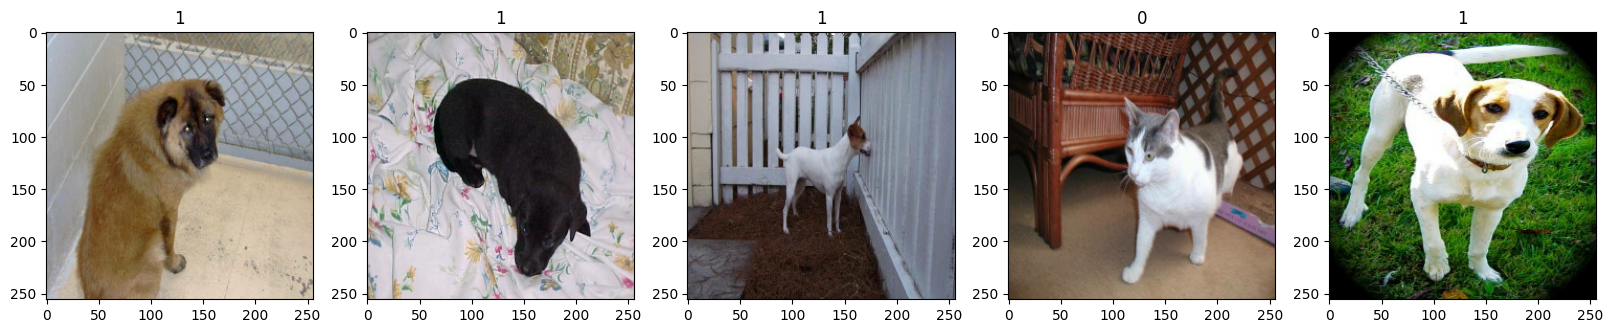

In [83]:
fig, ax = plt.subplots(ncols=5, figsize=(20,20))
for idx, img in enumerate(batch[0][:5]):
    ax[idx].imshow(img.astype(int))
    ax[idx].title.set_text(batch[1][idx])

In [84]:
data = data.map(lambda x,y: (x/255, y))

In [85]:
data.as_numpy_iterator().next()

(array([[[[0.2256115 , 0.20599021, 0.16395527],
          [0.26376602, 0.26455104, 0.2152021 ],
          [0.27163833, 0.29592288, 0.23869564],
          ...,
          [0.14490479, 0.31961688, 0.37530637],
          [0.15841417, 0.26345965, 0.28270173],
          [0.193443  , 0.2580723 , 0.24693565]],
 
         [[0.15988605, 0.16414663, 0.11807775],
          [0.23683801, 0.260109  , 0.20746654],
          [0.24360505, 0.29289448, 0.231848  ],
          ...,
          [0.10457497, 0.27310875, 0.3348122 ],
          [0.07919859, 0.18942542, 0.2162177 ],
          [0.0975548 , 0.1720646 , 0.1755266 ]],
 
         [[0.13470337, 0.17254351, 0.1245642 ],
          [0.19134498, 0.24654564, 0.19124128],
          [0.19086283, 0.27359873, 0.20979781],
          ...,
          [0.0961079 , 0.25183746, 0.3218589 ],
          [0.07234631, 0.18021066, 0.2248238 ],
          [0.10419593, 0.18631732, 0.20993413]],
 
         ...,
 
         [[0.23637545, 0.22068918, 0.21684696],
          [0.48195

In [86]:
train_size = int(len(data)*.7) #70% train
val_size = int(len(data)*.2) #20% validation
test_size = int(len(data)*.1)#10% test

In [87]:
train = data.take(train_size)
val = data.skip(train_size).take(val_size)
test = data.skip(train_size+val_size).take(test_size)

In [88]:
from tensorflow.keras.models import Sequential #singl input and singl output
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout

In [89]:
model = Sequential()

In [90]:
model.add(Conv2D(16,(3,3),1,activation='relu',input_shape = (256,256,3)))
model.add(MaxPooling2D())
model.add(Conv2D(32,(3,3),1,activation='relu'))
model.add(MaxPooling2D())
model.add(Conv2D(16,(3,3),1,activation='relu'))
model.add(MaxPooling2D())
model.add(Flatten())
model.add(Dense(256,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [91]:
model.compile('adam',loss=tf.losses.BinaryCrossentropy(),metrics=['accuracy'])

In [92]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 254, 254, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 127, 127, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 125, 125, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 62, 62, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 60, 60, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 30, 30, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 14400)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     3,686,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,696,625 (14.10 MB)

 Trainable params: 3,696,625 (14.10 MB)

 Non-trainable params: 0 (0.00 B)

In [93]:
logdir = 'logs'

In [94]:
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=logdir)

In [95]:
hist = model.fit(train,epochs=25,validation_data=val,callbacks=tensorboard_callback)

Epoch 1/25
175/175 ━━━━━━━━━━━━━━━━━━━━ 23s 108ms/step - accuracy: 0.5639 - loss: 0.6993 - val_accuracy: 0.6106 - val_loss: 0.6679
Epoch 2/25
175/175 ━━━━━━━━━━━━━━━━━━━━ 20s 112ms/step - accuracy: 0.6375 - loss: 0.6431 - val_accuracy: 0.6750 - val_loss: 0.6151
Epoch 3/25
175/175 ━━━━━━━━━━━━━━━━━━━━ 19s 108ms/step - accuracy: 0.7057 - loss: 0.5724 - val_accuracy: 0.6975 - val_loss: 0.5924
Epoch 4/25
175/175 ━━━━━━━━━━━━━━━━━━━━ 19s 110ms/step - accuracy: 0.7777 - loss: 0.4691 - val_accuracy: 0.7063 - val_loss: 0.6018
Epoch 5/25
175/175 ━━━━━━━━━━━━━━━━━━━━ 20s 111ms/step - accuracy: 0.8414 - loss: 0.3392 - val_accuracy: 0.7050 - val_loss: 0.6900
Epoch 6/25
175/175 ━━━━━━━━━━━━━━━━━━━━ 19s 107ms/step - accuracy: 0.9168 - loss: 0.1966 - val_accuracy: 0.6969 - val_loss: 0.8915
Epoch 7/25
175/175 ━━━━━━━━━━━━━━━━━━━━ 20s 114ms/step - accuracy: 0.9554 - loss: 0.1272 - val_accuracy: 0.7006 - val_loss: 1.0656
Epoch 8/25
175/175 ━━━━━━━━━━━━━━━━━━━━ 19s 106ms/step - accuracy: 0.9782 - loss: 0

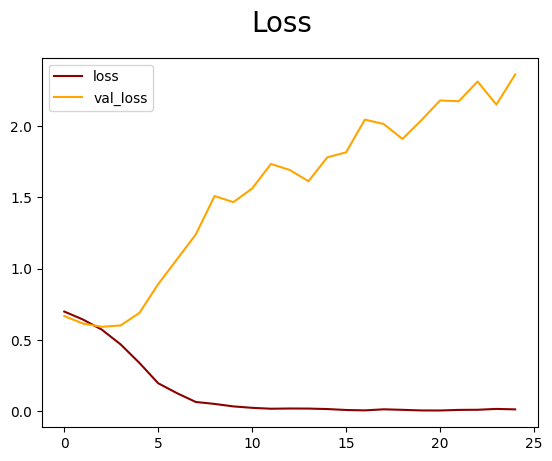

In [96]:
fig = plt.figure()
plt.plot(hist.history['loss'], color='darkred', label='loss')
plt.plot(hist.history['val_loss'], color='orange', label='val_loss')
fig.suptitle('Loss', fontsize=20)
plt.legend(loc="upper left")
plt.show()

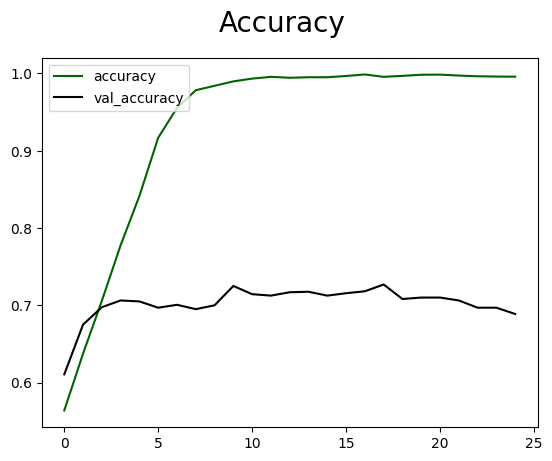

In [97]:
fig = plt.figure()
plt.plot(hist.history['accuracy'], color='darkgreen', label='accuracy')
plt.plot(hist.history['val_accuracy'], color='k', label='val_accuracy')
fig.suptitle('Accuracy', fontsize=20)
plt.legend(loc="upper left")
plt.show()

In [98]:
from tensorflow.keras.metrics import Precision, Recall, BinaryAccuracy

In [99]:
Pre = Precision()
Re = Recall()
Acc = BinaryAccuracy()

In [100]:
for batch in test.as_numpy_iterator():
    X, y = batch
    yhat = model.predict(X)
    Pre.update_state(y, yhat)
    Re.update_state(y, yhat)
    Acc.update_state(y, yhat)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 517ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step


In [101]:
Pre.result()

<tf.Tensor: shape=(), dtype=float32, numpy=0.7139107584953308>

In [102]:
print(Re.result())

tf.Tensor(0.635514, shape=(), dtype=float32)


In [103]:
print(Acc.result())

tf.Tensor(0.66875, shape=(), dtype=float32)


In [104]:
import cv2

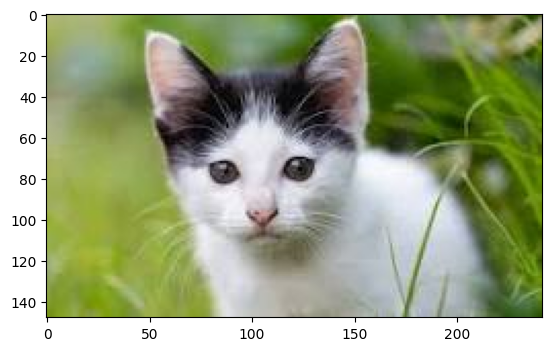

In [105]:
img = cv2.imread('/content/cat.jpg')
img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
plt.imshow(img)
plt.show()

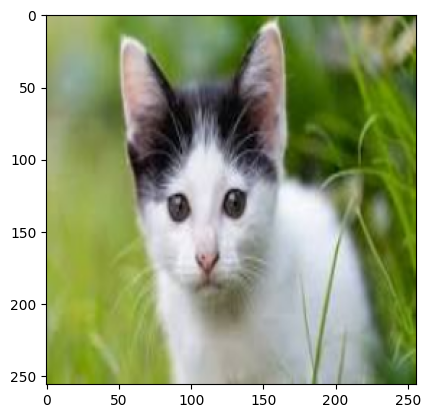

In [106]:
resize = tf.image.resize(img, (256,256))
plt.imshow(resize.numpy().astype(int))
plt.show()

In [107]:
yhat = model.predict(np.expand_dims(resize/255, 0))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 439ms/step


In [108]:
yhat

array([[0.9999908]], dtype=float32)

In [117]:
if yhat > 0.5:
    print(f'Predicted class is dog')
else:
    print(f'Predicted class is cat')

Predicted class is cat


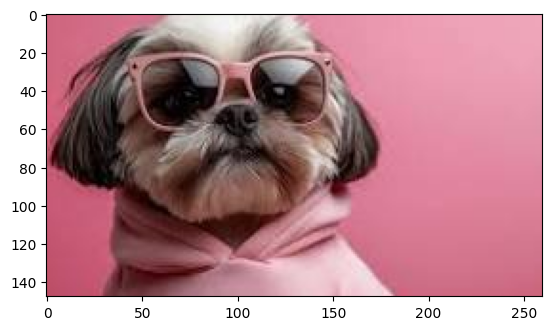

In [110]:
img = cv2.imread('/content/dog.jpg')
img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
plt.imshow(img)
plt.show()

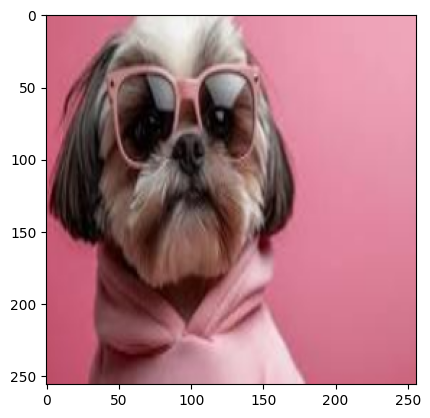

In [111]:
resize = tf.image.resize(img, (256,256))
plt.imshow(resize.numpy().astype(int))
plt.show()

In [112]:
yhat = model.predict(np.expand_dims(resize/255, 0))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


In [113]:
yhat

array([[2.4319348e-07]], dtype=float32)

In [118]:
if yhat > 0.5:
    print(f'Predicted class is cat')
else:
    print(f'Predicted class is dog')

Predicted class is dog


In [115]:
model.save(os.path.join('models','image_classifier_models.h5'))